In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Dataset (Study Hours vs Exam Score)
X = np.array([1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5,
              6.0, 6.5, 7.0, 7.5, 8.0]).reshape(-1, 1)

y = np.array([35, 40, 50, 55, 60, 65, 70, 75, 78, 82,
              85, 88, 90, 92, 95])

In [5]:
import pandas as pd
df = pd.DataFrame({'Study Hours': X.flatten(), 'Exam Score': y})


,Study Hours,Exam Score
0,1.0,35
1,1.5,40
2,2.0,50
3,2.5,55
4,3.0,60
5,3.5,65
6,4.0,70
7,4.5,75
8,5.0,78
9,5.5,82


np.float64(-0.5458332367723105)

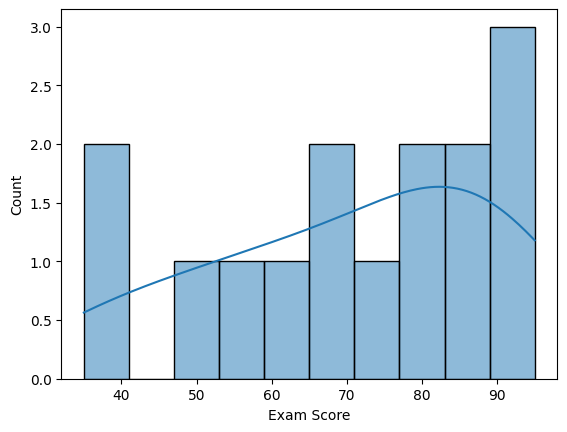

In [10]:
#basic eda
import seaborn as sns
y =df['Exam Score']
y.head()

#target variable distributions

sns.histplot(data = df, x = 'Exam Score', bins = 10, kde = True)
# target variable is left skewed
y.skew() #-0.54 confirmed

np.float64(-1.1999999999999997)

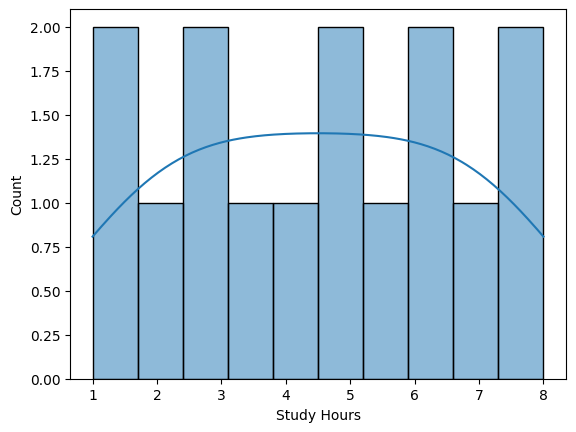

In [15]:
# let us plot features
sns.histplot(data = df, x = 'Study Hours', bins = 10, kde = True)
# largely normal but kurtosis is low
X = df['Study Hours']
X.kurt() # -1.99 # it is flatter than normalz

<Axes: xlabel='Exam Score'>

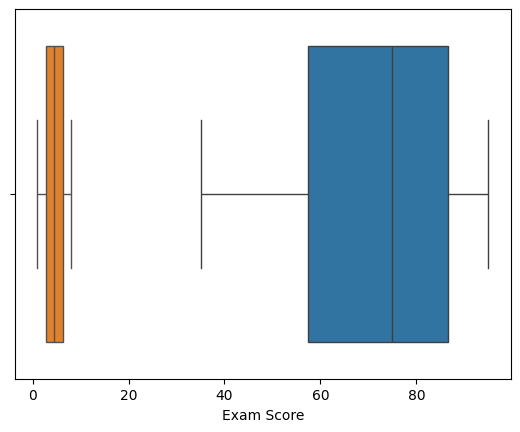

In [17]:
# there is no need for correlation analysis
# checking outliers
sns.boxplot(x=df['Exam Score']) # no outliers as such

<Axes: xlabel='Study Hours'>

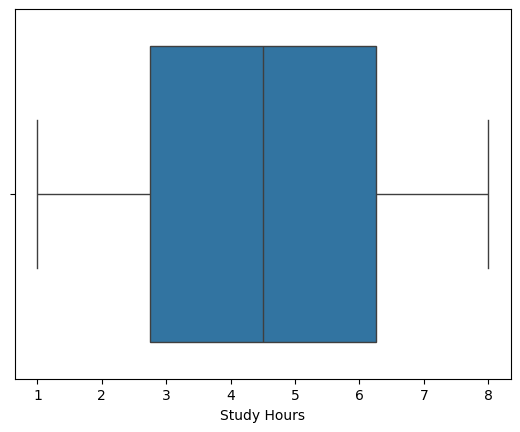

In [18]:
sns.boxplot(x= df['Study Hours']) # 1-8, and usualyl 3-6

In [27]:
X = df[['Study Hours']]   # double brackets → DataFrame (2D)
y = df['Exam Score']

reg = LinearRegression()
reg.fit(X, y)

LinearRegression()

In [28]:
reg.coef_

array([8.43571429])

In [29]:
reg.intercept_

np.float64(32.7059523809524)

In [30]:
reg.predict(X)

array([ 41.14166667,  45.35952381,  49.57738095,  53.7952381 ,
        58.01309524,  62.23095238,  66.44880952,  70.66666667,
        74.88452381,  79.10238095,  83.3202381 ,  87.53809524,
        91.75595238,  95.97380952, 100.19166667])

In [32]:
r2_score(y, reg.predict(X)) # 0.965
mean_squared_error(y, reg.predict(X))  #11.869 --> can minimize

11.869603174603174

In [38]:
y_pred = reg.predict(X)


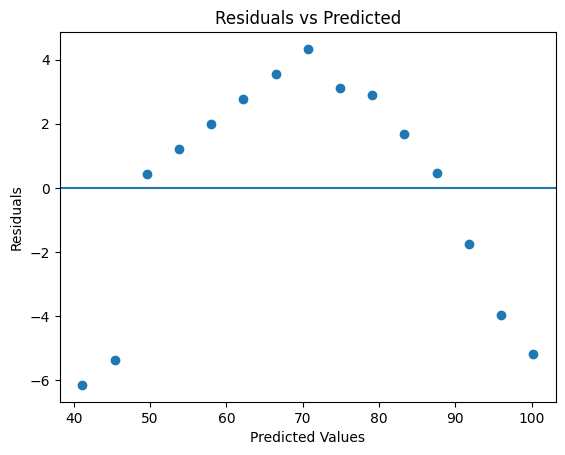

In [39]:
import matplotlib.pyplot as plt

residuals = y - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

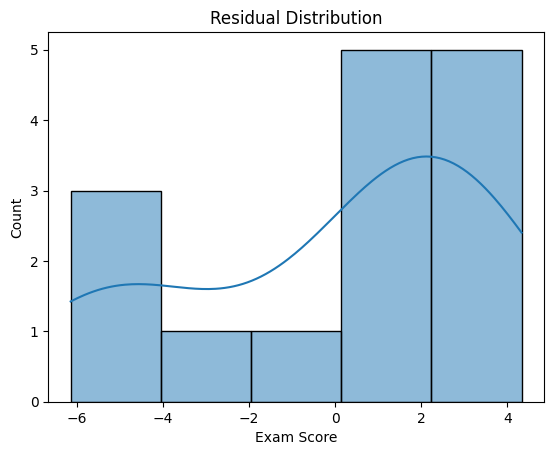

In [40]:
import seaborn as sns

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()
# not normal

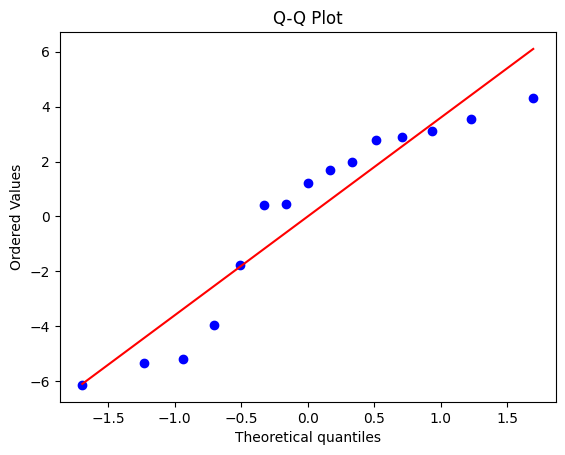

In [41]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

In [42]:
print(residuals.describe())

count    1.500000e+01
mean    -4.736952e-15
std      3.566151e+00
min     -6.141667e+00
25%     -2.864881e+00
50%      1.204762e+00
75%      2.833333e+00
max      4.333333e+00
Name: Exam Score, dtype: float64
